**Goal:** hand L13's chi-square survivors to a model that sees features *together* -- a decision tree you
can read aloud and a random forest -- and measure what selection actually costs against an honest baseline.
Pairs with the concept note [Feature Selection II: Trees & Random Forests](l14_concept_feature_selection_trees.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u04_data_mining/l14_lab_feature_selection_trees.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l14_lab_feature_selection_trees.ipynb`) -- in Colab via the badge above, or locally. Every text output
> below comes from actually running the cells; the forest's importance bar chart renders live in the
> notebook.

> **Where this sits:** **closes Unit IV.** L13 ranked features model-free; here a model selects them while
> seeing them together. The full engineer -> select -> model -> interpret loop is the mini-project (**L15**).

## Prerequisites & Setup

Run this first. Same dataset and matrix as L12/L13 -- the **SMS Spam Collection** (Almeida, Gomez Hidalgo &
Yamakami 2011; UCI id 228, CC BY 4.0), bundled as `data/sms_spam.csv` with a UCI fallback.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + rebuild L12/L13's feature matrix X (5574 x 2003) and label y
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier

LOCAL = "data/sms_spam.csv"
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
if os.path.exists(LOCAL):
    sms = pd.read_csv(LOCAL)
else:
    import io, zipfile, urllib.request
    with urllib.request.urlopen(URL) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    sms = pd.read_table(z.open("SMSSpamCollection"), header=None,
                        names=["label", "message"], quoting=3)

sms["length"] = sms["message"].str.len()
sms["digit_count"] = sms["message"].str.count(r"\d")
sms["exclam_count"] = sms["message"].str.count("!")
vectorizer = CountVectorizer(stop_words="english", max_features=2000)
X_counts = vectorizer.fit_transform(sms["message"])
handcrafted = ["length", "digit_count", "exclam_count"]
X = hstack([X_counts, csr_matrix(sms[handcrafted].values)]).tocsr()
feature_names = np.array(list(vectorizer.get_feature_names_out()) + handcrafted)
y = (sms["label"] == "spam").astype(int)
print("Feature matrix:", X.shape)

Feature matrix: (5574, 2003)


<details><summary>Expected Output</summary>

~~~text
Feature matrix: (5574, 2003)
~~~
</details>

## Step 1: An Honest Yardstick -- Baseline and Train/Test Split (Worked)

Before scoring anything, two pieces of discipline. First, the **baseline**: 86.6% of messages are ham, so
"predict ham for everything" is the score to beat. Second, the **train/test split**: every learned step
from here on -- selection included -- is fit on 70% of the data and graded on the 30% it never saw.

In [3]:
print(f"Majority-class baseline: predict 'ham' for everything -> {(y == 0).mean():.1%} accuracy")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training messages:", X_train.shape[0])
print("Test messages:    ", X_test.shape[0])
print(f"Spam share -- train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

Majority-class baseline: predict 'ham' for everything -> 86.6% accuracy
Training messages: 3901
Test messages:     1673
Spam share -- train: 13.4%, test: 13.4%


<details><summary>Expected Output</summary>

~~~text
Majority-class baseline: predict 'ham' for everything -> 86.6% accuracy
Training messages: 3901
Test messages:     1673
Spam share -- train: 13.4%, test: 13.4%
~~~
</details>

> **Read it:** `stratify=y` keeps the spam share identical (13.4%) on both sides -- without it, chance could
> hand the test set a different class mix and quietly distort every accuracy. From here on, nothing learns
> from `X_test`.

## Step 2: Filter, Then a Tree You Can Read Aloud (Worked)

Apply L13's chi-square filter -- **fit on the training split only** (the discipline L13 named) -- keep the
top 30, and hand them to a decision tree with a strict honesty budget: at most three questions per message
(`max_depth=3`).

In [4]:
selector = SelectKBest(chi2, k=30).fit(X_train, y_train)   # fit on TRAIN only
kept = feature_names[selector.get_support()]
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

tree_sel = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_sel.fit(X_train_sel, y_train)

print(export_text(tree_sel, feature_names=list(kept)))
print(f"Test accuracy: {tree_sel.score(X_test_sel, y_test):.1%}")

|--- digit_count <= 4.50
|   |--- www <= 0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 0
|   |   |--- mobile >  0.50
|   |   |   |--- class: 1
|   |--- www >  0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 1
|   |   |--- mobile >  0.50
|   |   |   |--- class: 0
|--- digit_count >  4.50
|   |--- digit_count <= 9.50
|   |   |--- length <= 176.00
|   |   |   |--- class: 1
|   |   |--- length >  176.00
|   |   |   |--- class: 0
|   |--- digit_count >  9.50
|   |   |--- length <= 182.00
|   |   |   |--- class: 1
|   |   |--- length >  182.00
|   |   |   |--- class: 0

Test accuracy: 97.8%


<details><summary>Expected Output</summary>

~~~text
|--- digit_count <= 4.50
|   |--- www <= 0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 0
|   |   |--- mobile >  0.50
|   |   |   |--- class: 1
|   |--- www >  0.50
|   |   |--- mobile <= 0.50
|   |   |   |--- class: 1
|   |   |--- mobile >  0.50
|   |   |   |--- class: 0
|--- digit_count >  4.50
|   |--- digit_count <= 9.50
|   |   |--- length <= 176.00
|   |   |   |--- class: 1
|   |   |--- length >  176.00
|   |   |   |--- class: 0
|   |--- digit_count >  9.50
|   |   |--- length <= 182.00
|   |   |   |--- class: 1
|   |   |--- length >  182.00
|   |   |   |--- class: 0

Test accuracy: 97.8%
~~~
</details>

> **Read it** (class 0 = ham, 1 = spam): *"Fewer than five digits? Then it's ham -- unless it mentions 'www'
> or 'mobile'. Five or more digits? Then it's spam -- unless it's suspiciously long."* The root split -- the
> single most valuable question among all 30 features -- is `digit_count`, the column you invented with one
> line of `str.count` in L11/L12. And this readable rule scores 97.8% on messages it never saw, against an
> 86.6% baseline.

## Step 3: The Showdown -- 30 Features vs 2,003 (Worked)

What did selection cost? Fit the identical tree on the full matrix and compare.

In [5]:
tree_all = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_all.fit(X_train, y_train)

results = [
    (f"Depth-3 tree, all {X_train.shape[1]:,} features", tree_all.score(X_test, y_test)),
    ("Depth-3 tree, top 30 features", tree_sel.score(X_test_sel, y_test)),
    ("Majority-class baseline", (y_test == 0).mean()),
]
for name, acc in results:
    print(f"{name:<36} {acc:.1%}")

Depth-3 tree, all 2,003 features     98.0%
Depth-3 tree, top 30 features        97.8%
Majority-class baseline              86.6%


<details><summary>Expected Output</summary>

~~~text
Depth-3 tree, all 2,003 features     98.0%
Depth-3 tree, top 30 features        97.8%
Majority-class baseline              86.6%
~~~
</details>

> **Read it:** dropping 1,973 features cost 0.2 percentage points. Thirty columns do the work of two
> thousand, because the signal was concentrated in a handful of features all along.

## Step 4: The Random Forest -- Accuracy and a Second Opinion (Worked + Completion)

A forest grows 200 randomized trees and lets them vote. Collect its accuracy, and its feature-importance
ranking -- a second, independent opinion on which features matter.

In [6]:
forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)
print(f"Random forest, all features: {forest.score(X_test, y_test):.1%}")

Random forest, all features: 99.1%


<details><summary>Expected Output</summary>

~~~text
Random forest, all features: 99.1%
~~~
</details>

> **Read it:** 1.3 points above the top-30 tree and 12.5 above the baseline -- the vote of 200 trees is the
> most accurate model in this lab. Hold the "is that worth it?" question for Exercise 3.

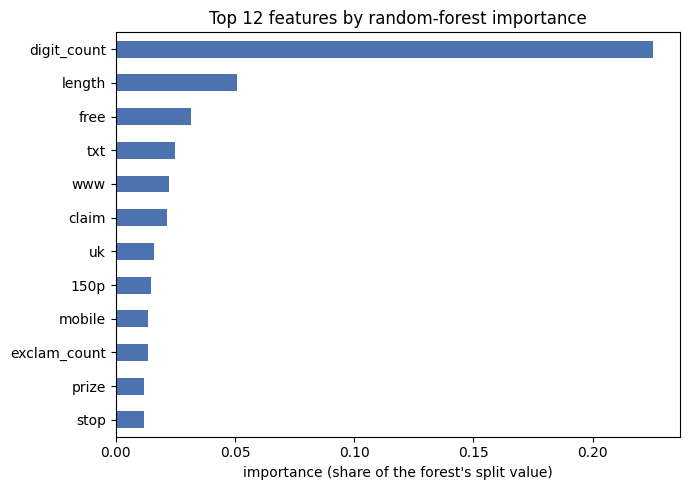

In [7]:
importances = pd.Series(forest.feature_importances_, index=feature_names)
top12 = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
top12.sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("importance (share of the forest's split value)")
ax.set_title("Top 12 features by random-forest importance")
plt.tight_layout()
plt.show()

> **Read it:** compare this leaderboard with L13's chi-square ranking: `digit_count` and `length` on top,
> then free, txt, www, claim. The filter and the forest share no machinery -- one is a statistical test, the
> other an average over 200 trees -- yet they crown the same features. When two unrelated methods agree on
> what matters, that agreement is evidence.

The forest can also tell us how much of the matrix it *ignores*:

In [8]:
# COMPLETION: count the features whose importance is below 0.0001 (they contribute
# essentially nothing to the forest's votes). Fill the ____ and uncomment both lines.
# n_ignored = (importances < ____).sum()
# print(f"{n_ignored} of {len(importances)} features have importance below 0.0001")

<details><summary>Expected Output (after completing <code>0.0001</code>)</summary>

~~~text
1280 of 2003 features have importance below 0.0001
~~~
*(Nearly two thirds of the matrix is dead weight even to the model that uses all of it -- the forest quietly
performs its own feature selection.)*
</details>

## Your Turn

### Exercise 1 -- Turn the knobs

How sensitive is the result to our choices? Re-run the select-then-tree pipeline with `k=10` and `k=100`
(depth 3), and with `max_depth=2` and `max_depth=5` (k=30). Print the four test accuracies and write one
sentence on what you observe.

In [9]:
# Your Turn 1: loop over the k values and depths; only the SelectKBest(k=...) and
# DecisionTreeClassifier(max_depth=...) arguments change. Use fresh variable names.

<details><summary>Answer (one possible answer -- match the values, not the print format)</summary>

~~~text
k= 10, depth=3: 97.8%
k=100, depth=3: 97.8%
k= 30, depth=2: 97.5%
k= 30, depth=5: 97.7%
~~~
*(A plateau: ten features or a hundred, two questions or five, the accuracy barely moves. Once digit_count
and a few spam words are in, the rest add almost nothing -- the signal really is that concentrated.)*
</details>

### Exercise 2 -- Read the mistakes

The top-30 tree gets 97.8% right. Look at what it gets *wrong*: predict on the test set, count the
misclassified messages, and print the first three with their true labels (the first 90 characters is
plenty). One sentence: what fooled the tree?

In [10]:
# Your Turn 2: tree_sel.predict(X_test_sel) gives predictions;
# y_test.index[y_test.values != y_pred] gives the original row numbers of the mistakes.

<details><summary>Answer (one possible answer -- match the values, not the print format)</summary>

~~~text
Misclassified: 37 of 1673 test messages
  true=ham: 1Apple/Day=No Doctor. 1Tulsi Leaf/Day=No Cancer. 1Lemon/Day=No Fat. 1Cup Milk/day=No Bone
  true=spam: Your weekly Cool-Mob tones are ready to download !This weeks new Tones include: 1) Crazy F
  true=ham: .Please charge my mobile when you get up in morning.
~~~
*(The tree fails exactly where its features mislead: a chain-letter ham stuffed with digits reads as spam; a
ham containing "mobile" trips the www/mobile branch; a spam ad happens to dodge the thresholds. A model's
mistakes are a map of its features' blind spots.)*
</details>

### Exercise 3 -- Written: argue the case

A teammate looks at Step 4 and says: *"The forest gets 99.1%, the tree only 97.8% -- always ship the
forest."* Argue for or against in 3-4 sentences, using at least one piece of evidence from this lab.
Consider what this unit is named after: extracting *information* from data.

> **Hint:** what can you hand to a boss, an auditor, or a curious user from the depth-3 tree that the
> 200-tree forest cannot produce? And when would that argument flip?

## Summary

| Move | Key command | What you learned |
|------|-------------|------------------|
| Honest yardstick | `train_test_split(stratify=y)`, baseline | 86.6% is the score to beat, not 0% |
| Filter then tree | `SelectKBest(k=30)`, `DecisionTreeClassifier(max_depth=3)` | A 3-question rule scores 97.8% |
| The showdown | same tree, both matrices | 30 features do the work of 2,003 (98.0% vs 97.8%) |
| Random forest | `RandomForestClassifier`, `.feature_importances_` | 99.1% accuracy, but the explanation is gone |
| What it ignores | `(importances < 0.0001).sum()` | 1,280 of 2,003 features are dead weight |

Unit IV closes here: you defined features from raw data (L11/L12) and extracted the ones that carry
information (L13/L14). Next, **L15** -- the data-mining mini-project -- runs the whole loop end to end on a
fresh dataset.